# Amazon Domain — EDA

In [1]:
import sys
import warnings
from pathlib import Path

import gcsfs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

root = Path.cwd()
while not (root / "CLAUDE.md").exists():
    root = root.parent
sys.path.insert(0, str(root))

from config.config import load_config

cfg = load_config("amazon_domain")

RAW_COLS = [
    "EstacaoCod", "year", "month",
    "Prec", "tmax", "tmin", "ET", "vpd", "DrangAr",
    "vazao", "AF", "BA",
]
COL_RENAME = {
    "EstacaoCod": "station_id",
    "Prec":       "precip",
    "ET":         "et",
    "DrangAr":    "drainage_area",
    "vazao":      "discharge",
    "AF":         "active_fire_count",
    "BA":         "burned_area",
}
DYNAMIC = ["precip", "tmax", "tmin", "et", "vpd", "drainage_area"]
TARGETS = ["discharge", "active_fire_count", "burned_area"]

print("Config loaded. Bucket:", cfg["gcs"]["bucket"])

Config loaded. Bucket: gs://fr_v1/am_hydro_fire_risk_V2


In [2]:
fs     = gcsfs.GCSFileSystem(token="google_default")
bucket = cfg["gcs"]["bucket"]
files  = cfg["gcs"]["files"]

with fs.open(f"{bucket}/{files['fire_risk_monthly']}") as f:
    raw = pd.read_csv(f, usecols=RAW_COLS)

with fs.open(f"{bucket}/{files['station_list']}") as f:
    stations = pd.read_csv(f)

valid_ids = set(stations["x"].astype(str))
df = raw.rename(columns=COL_RENAME)
df = df[df["station_id"].astype(str).isin(valid_ids)].copy()
df["station_id"] = df["station_id"].astype(str)

print(f"Raw shape:              {raw.shape}")
print(f"After allowlist filter: {df.shape}")
print(f"Unique stations:        {df['station_id'].nunique()}")
print(f"Year range:             {df['year'].min()}\u2013{df['year'].max()}")

Raw shape:              (48264, 12)
After allowlist filter: (25836, 12)
Unique stations:        98
Year range:             2000–2024


## 1. Station & Time Coverage

Total stations:                98
Median temporal span (years):  25
Stations with temporal gaps:   0
Total gap-months (all stns):   0


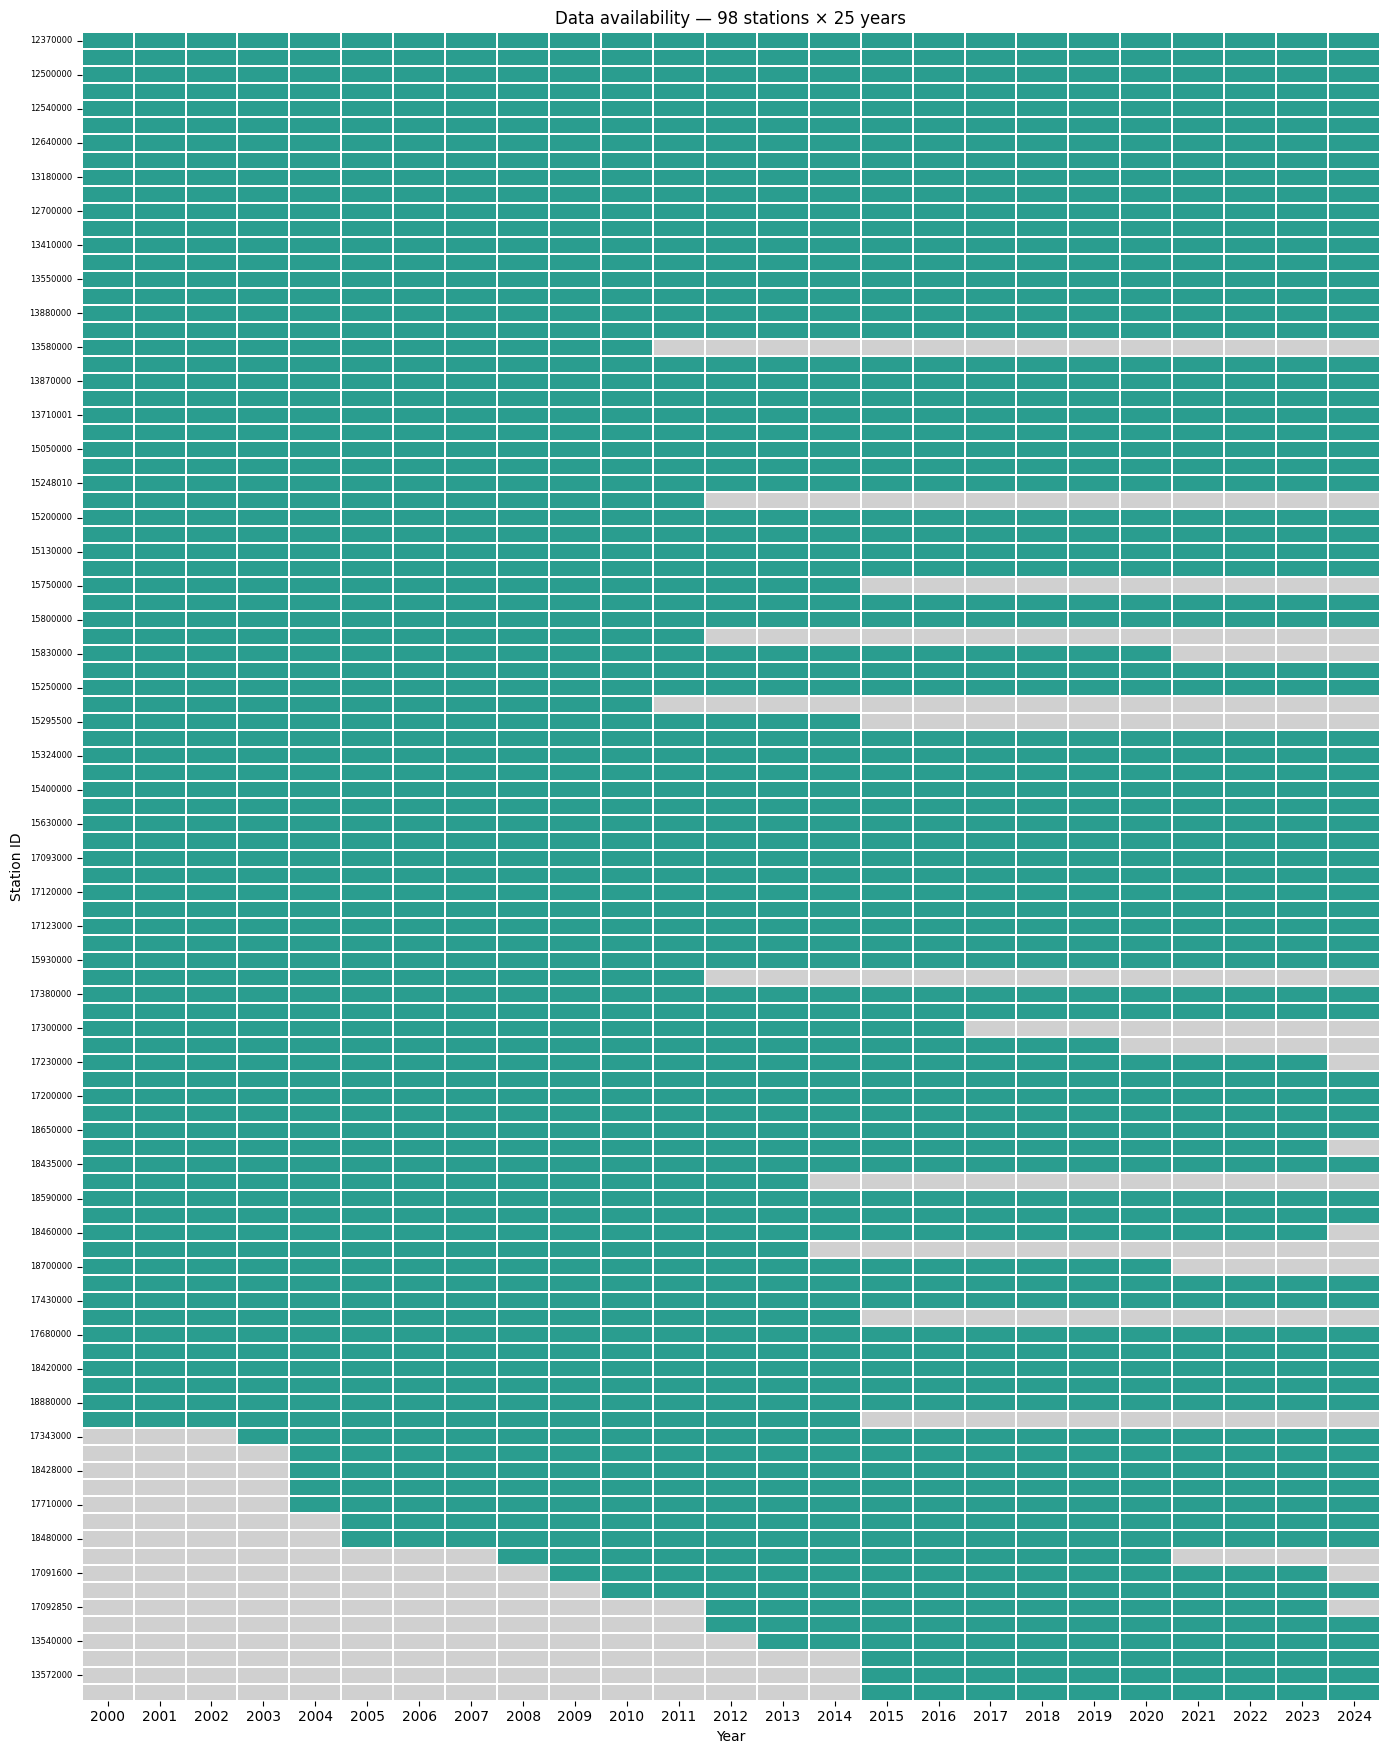

In [3]:
span = df.groupby("station_id").agg(
    first_year=("year", "min"),
    last_year=("year", "max"),
)
span["span_years"] = span["last_year"] - span["first_year"] + 1

gap_stations = 0
gap_months   = 0
for sid, grp in df.groupby("station_id"):
    grp   = grp.sort_values(["year", "month"])
    first = pd.Timestamp(int(grp["year"].iloc[0]),  int(grp["month"].iloc[0]),  1)
    last  = pd.Timestamp(int(grp["year"].iloc[-1]), int(grp["month"].iloc[-1]), 1)
    expected = len(pd.date_range(first, last, freq="MS"))
    missing  = expected - len(grp)
    if missing > 0:
        gap_stations += 1
        gap_months   += missing

print(f"Total stations:                {len(span)}")
print(f"Median temporal span (years):  {span['span_years'].median():.0f}")
print(f"Stations with temporal gaps:   {gap_stations}")
print(f"Total gap-months (all stns):   {gap_months}")

# Station × year availability heatmap
avail     = df.groupby(["station_id", "year"]).size().unstack(fill_value=0)
avail_bin = (avail > 0).astype(int)
first_yr  = avail_bin.apply(lambda r: avail_bin.columns[r.values.argmax()], axis=1)
avail_sorted = avail_bin.loc[first_yr.sort_values().index]

fig, ax = plt.subplots(figsize=(14, max(6, len(avail_sorted) * 0.18)))
sns.heatmap(
    avail_sorted,
    cmap=["#d0d0d0", "#2a9d8f"],
    cbar=False, ax=ax,
    linewidths=0.3, linecolor="white",
)
ax.set_xlabel("Year")
ax.set_ylabel("Station ID")
ax.set_title(f"Data availability \u2014 {len(avail_sorted)} stations \u00d7 {avail_sorted.shape[1]} years")
ax.tick_params(axis="y", labelsize=6)
plt.tight_layout()
plt.show()

## 2. Variable Descriptions

**Dynamic predictors**

- **precip** (`Prec`): Monthly total precipitation (mm). Strongly seasonal in the Amazon — primary driver of discharge and a suppressor of fire. Note: raw values are in watershed-scaled units (large for large watersheds).
- **tmax** (`tmax`): Monthly maximum air temperature (°C). Elevates evapotranspiration demand and fire risk during the dry season.
- **tmin** (`tmin`): Monthly minimum air temperature (°C). Paired with `tmax`; together they bracket the thermal range of the watershed.
- **et** (`ET`): Monthly evapotranspiration (mm, watershed-scaled). Integrates temperature, radiation, and moisture availability — key component of the water balance.
- **vpd** (`vpd`): Vapor pressure deficit (kPa). Atmospheric dryness indicator; a strong proxy for fire danger and plant water stress.
- **drainage_area** (`DrangAr`): Watershed drainage area (km²). Time-invariant per station; treated as a dynamic column but constant across all months for a given station. Controls the scale of discharge and fire totals.

**Targets**

- **discharge** (`vazao`): Monthly river discharge (m³/s). Primary hydrological target. ~6.3% NaN — kept as-is, masked during loss computation.
- **active_fire_count** (`AF`): Monthly count of active fire detections (MODIS) within the watershed. Zero-inflated during the wet season; spikes sharply in Aug–Oct.
- **burned_area** (`BA`): Monthly burned area (km²) within the watershed. Highly right-skewed; near-zero for most stations in most months, with extreme values during severe dry seasons.

## 3. Summary Statistics

In [4]:
def summary_table(data: pd.DataFrame, cols: list, label: str) -> None:
    desc = data[cols].describe().T.round(2)
    desc["missing_%"] = (data[cols].isna().mean() * 100).round(1)
    print(f"\n{label}")
    display(desc)

summary_table(df, DYNAMIC, "Predictors")
summary_table(df, TARGETS,  "Targets")


Predictors


,count,mean,std,min,25%,50%,75%,max,missing_%
precip,25836.0,5679.37,12901.33,0.00,275.68,1081.42,4442.18,124086.13,0.0
tmax,25836.0,31.37,1.73,23.98,30.26,31.10,32.31,40.70,0.0
tmin,25836.0,19.09,2.11,10.08,18.05,19.60,20.57,24.75,0.0
et,25836.0,3987.10,7446.39,1.96,298.44,1024.87,3684.41,44288.23,0.0
vpd,25836.0,0.89,0.34,0.20,0.65,0.78,1.05,3.33,0.0
drainage_area,25836.0,119585.50,230533.00,3009.34,11058.46,34533.26,110145.80,1144067.24,0.0



Targets


,count,mean,std,min,25%,50%,75%,max,missing_%
discharge,24206.0,2443.52,5740.35,0.0,117.07,435.64,1744.84,67309.57,6.3
active_fire_count,25836.0,441.15,2416.37,0.0,0.00,8.00,93.00,64449.00,0.0
burned_area,25836.0,222.18,1442.51,0.0,0.00,0.28,16.04,33171.60,0.0


## 4. Correlation: Dynamic Predictors × Targets

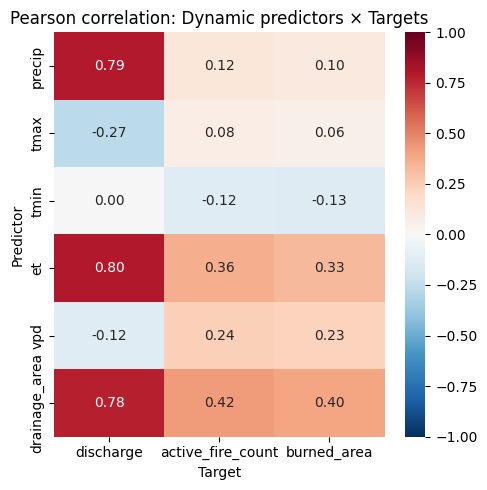

In [5]:
corr = df[DYNAMIC + TARGETS].corr().loc[DYNAMIC, TARGETS]

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(
    corr,
    cmap="RdBu_r", vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    ax=ax,
)
ax.set_title("Pearson correlation: Dynamic predictors \u00d7 Targets")
ax.set_xlabel("Target")
ax.set_ylabel("Predictor")
plt.tight_layout()
plt.show()

## EDA Results & Decisions

**Dataset:** 98 stations after filtering to the allowlist (25,836 rows), spanning 2000–2024. 100 stations in the raw file were excluded by the allowlist.

**Temporal coverage:** Stations vary in when they begin reporting (see availability heatmap above). Some stations have temporal gaps; all gaps will be filled with NaN rows during preprocessing to enforce contiguous monthly records per station before building sliding windows.

**Missing values:** Only `discharge` has NaN (6.3% of rows). All dynamic predictors and both fire targets (`active_fire_count`, `burned_area`) are fully observed. No imputation needed — NaN discharge values are kept as-is and masked during loss computation (applies to all 3 targets for generality).

**Value scale:** `precip` and `et` are in watershed-scaled units (mm × watershed area), leading to very large absolute values for large watersheds. `drainage_area` spans ~3 orders of magnitude across stations. StandardScaler normalisation at preprocessing time handles these scale differences.

**No outlier removal:** Extreme values in `precip`, `discharge`, `active_fire_count`, and `burned_area` are physically plausible events (large floods, severe fire seasons). Removing them would bias the model toward average conditions. Normalisation is sufficient.

**Correlation highlights:** *(see heatmap above for exact values)*
- `precip` and `et` correlate positively with `discharge` and negatively with fire targets.
- `vpd` and `tmax` correlate positively with `active_fire_count` and `burned_area`.
- `drainage_area` is the strongest single predictor of `discharge` magnitude (larger watersheds produce more flow).
- All predictors show moderate-to-weak correlation with fire targets at monthly scale — the transformer must learn lagged and non-linear relationships from sequences.

**Station completeness:** 10 stations have <50% completeness over 2000–2024. These are kept in training — their short records still contribute valid windows, and excluding them would reduce geographic coverage.

**Split strategy:** Station-level random split (70/15/15) rather than time-based. This evaluates generalisation to unseen watersheds — a harder and more realistic test than a time split. `random_seed = 42` for reproducibility.

**Sequence construction:** After preprocessing, each station’s contiguous monthly run forms a segment. Segments shorter than `seq_len` (12 months) are discarded.